# 9. Обучение GNN/GAT и проверка Graph-EVT pipeline

Ноутбук использует актуальные `EpisodeLabeler`, `ProcessModelTrainer` и `EvaluationOrchestrator`. Модель обучается на независимых синтетических записях с известными источниками; затем сравнивается на отложенных размеченных n-D эпизодах и запускается на двух запрошенных CSV: fractal 1-D и Kuramoto n-D. В реальных CSV ground truth источника не подменяется синтетической меткой.

Модель получает пять сводных признаков узла и baseline-граф. Progress bars показывают ход разметки, обучения и evaluation. Attention является весом предсказания, а не доказательством причинности.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from graph_evt_agent import (
    EVTConfig,
    EpisodeLabeler,
    EvaluationCase,
    EvaluationOrchestrator,
    GraphConfig,
    GraphEVTPipeline,
    GraphLearningConfig,
    LabelingConfig,
    ProcessModelTrainer,
    load_timeseries,
)
from graph_evt_agent import visualization as viz
from graph_evt_agent.synthetic import make_propagation_episode, make_recording
from graph_evt_agent.graph import build_graph

SEED = 42
N_CHANNELS = 12
BASELINE_SIZE = 300
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data/generated/kuramoto_synchronized_series.csv"
FRACTAL_PATH = ROOT / "data/generated/fractal_extreme_series.csv"

fractal_frame = pd.read_csv(FRACTAL_PATH)
dataframe = pd.read_csv(DATA_PATH)
channel_names = [column for column in dataframe.columns if column != "timestamp"]
observed_values = dataframe[channel_names].to_numpy(dtype=float)
print(f"1-D input: {FRACTAL_PATH.name}; n-D input: {DATA_PATH.name}")
print(f"Kuramoto shape: {observed_values.shape[0]} samples x {observed_values.shape[1]} channels")

1-D input: fractal_extreme_series.csv; n-D input: kuramoto_synchronized_series.csv
Kuramoto shape: 1500 samples x 12 channels


## 1. Входной ряд и baseline-граф

Граф ниже оценивается только по первым 300 точкам текущего ряда. Его рёбра обозначают неориентированную статистическую связь каналов; они не задают направление распространения и не раскрывают физическую причину. Один этот ряд не содержит набора независимых source-меток для обучения.

Graph method: ar_innovation_correlation; nodes: 12; undirected edges: 34
Channel order: ['channel_00', 'channel_01', 'channel_02', 'channel_03', 'channel_04', 'channel_05', 'channel_06', 'channel_07', 'channel_08', 'channel_09', 'channel_10', 'channel_11']


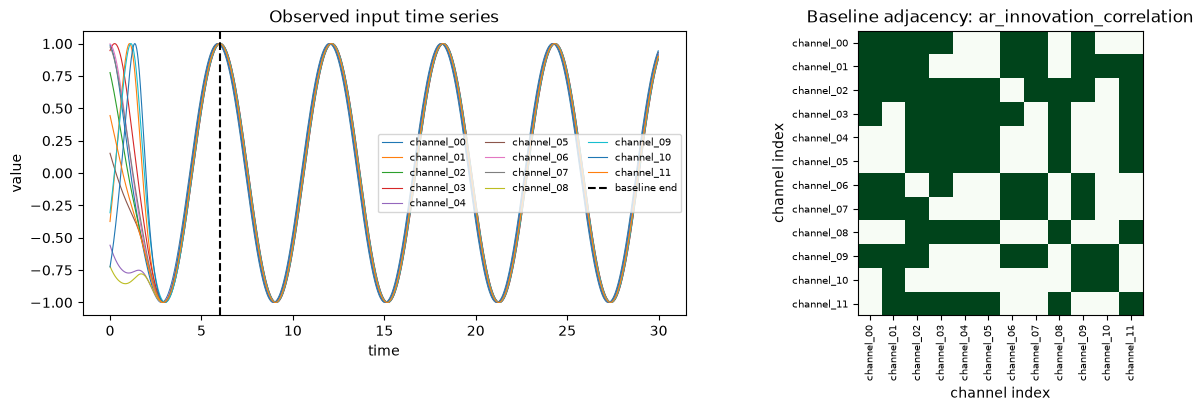

In [2]:
graph_result = build_graph(
    observed_values[:BASELINE_SIZE],
    GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
)
adjacency = graph_result.adjacency.astype(bool)
edge_count = int(np.triu(adjacency, k=1).sum())
print(f"Graph method: {graph_result.method}; nodes: {len(channel_names)}; undirected edges: {edge_count}")
print("Channel order:", channel_names)

figure, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for node_index, channel_name in enumerate(channel_names):
    axes[0].plot(dataframe["timestamp"], observed_values[:, node_index], linewidth=0.8, label=channel_name)
axes[0].axvline(dataframe["timestamp"].iloc[BASELINE_SIZE], color="black", linestyle="--", label="baseline end")
axes[0].set(title="Observed input time series", xlabel="time", ylabel="value")
axes[0].legend(fontsize=7, ncol=3)
axes[1].imshow(adjacency, cmap="Greens", vmin=0, vmax=1)
axes[1].set(title=f"Baseline adjacency: {graph_result.method}", xlabel="channel index", ylabel="channel index")
axes[1].set_xticks(range(len(channel_names)), channel_names, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(channel_names)), channel_names, fontsize=7)
plt.show()

## 2. Независимые размеченные эпизоды

Обучающий набор генерируется пакетным `make_recording`: каждая запись содержит четыре разделённых EVT-эпизода с известными источниками. `EpisodeLabeler` находит события численно, сопоставляет их с ручными синтетическими аннотациями и строит признаки узлов и baseline-граф; split ниже выполняется по целым записям.

In [3]:
labeling_pipeline = GraphEVTPipeline(
    EVTConfig(
        baseline_size=BASELINE_SIZE,
        tail_quantile=0.90,
        alarm_probability=0.99,
        top_k=3,
        persistence=2,
    ),
    GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
)
training_recordings = {}
training_annotations = {}
for recording_index in range(24):
    recording = make_recording(
        n_events=4,
        n_channels=N_CHANNELS,
        baseline_size=BASELINE_SIZE,
        gap=150,
        topology="ring",
        gain_jitter=0.45,
        seed=1_000 + recording_index,
    )
    recording_id = f"training_recording_{recording_index:02d}"
    training_recordings[recording_id] = recording.as_input()
    training_annotations[recording_id] = list(zip(recording.event_times, recording.sources))

labels = EpisodeLabeler(
    labeling_pipeline,
    LabelingConfig(refractory=50, match_tolerance=25),
    verbose=True,
).label(training_recordings, annotations=training_annotations)
print("Episode labels:", labels.summary())
print("Skipped recordings:", labels.skipped)
pd.DataFrame(labels.to_records()).head()

Labelling episodes:   0%|          | 0/24 [00:00<?, ?it/s]

Episode labels: {'episodes': 100, 'manual': 95, 'pseudo': 0, 'abstained': 5, 'skipped_series': 0}
Skipped recordings: ()


,series_id,event_time,source,source_name,origin,confidence,margin,graph_method
0,training_recording_00,375,9.0,ch9,manual,0.999997,0.999995,ar_innovation_correlation
1,training_recording_00,525,9.0,ch9,manual,0.994925,0.990028,ar_innovation_correlation
2,training_recording_00,675,8.0,ch8,manual,0.668520,0.337744,ar_innovation_correlation
3,training_recording_00,825,8.0,ch8,manual,0.998629,0.997273,ar_innovation_correlation
4,training_recording_01,375,11.0,ch11,manual,0.995226,0.990501,ar_innovation_correlation


Events in example recording: 4
   event_time source label_origin  confidence
0         375    ch9       manual    0.999997
1         525    ch9       manual    0.994925
2         675    ch8       manual    0.668520
3         825    ch8       manual    0.998629


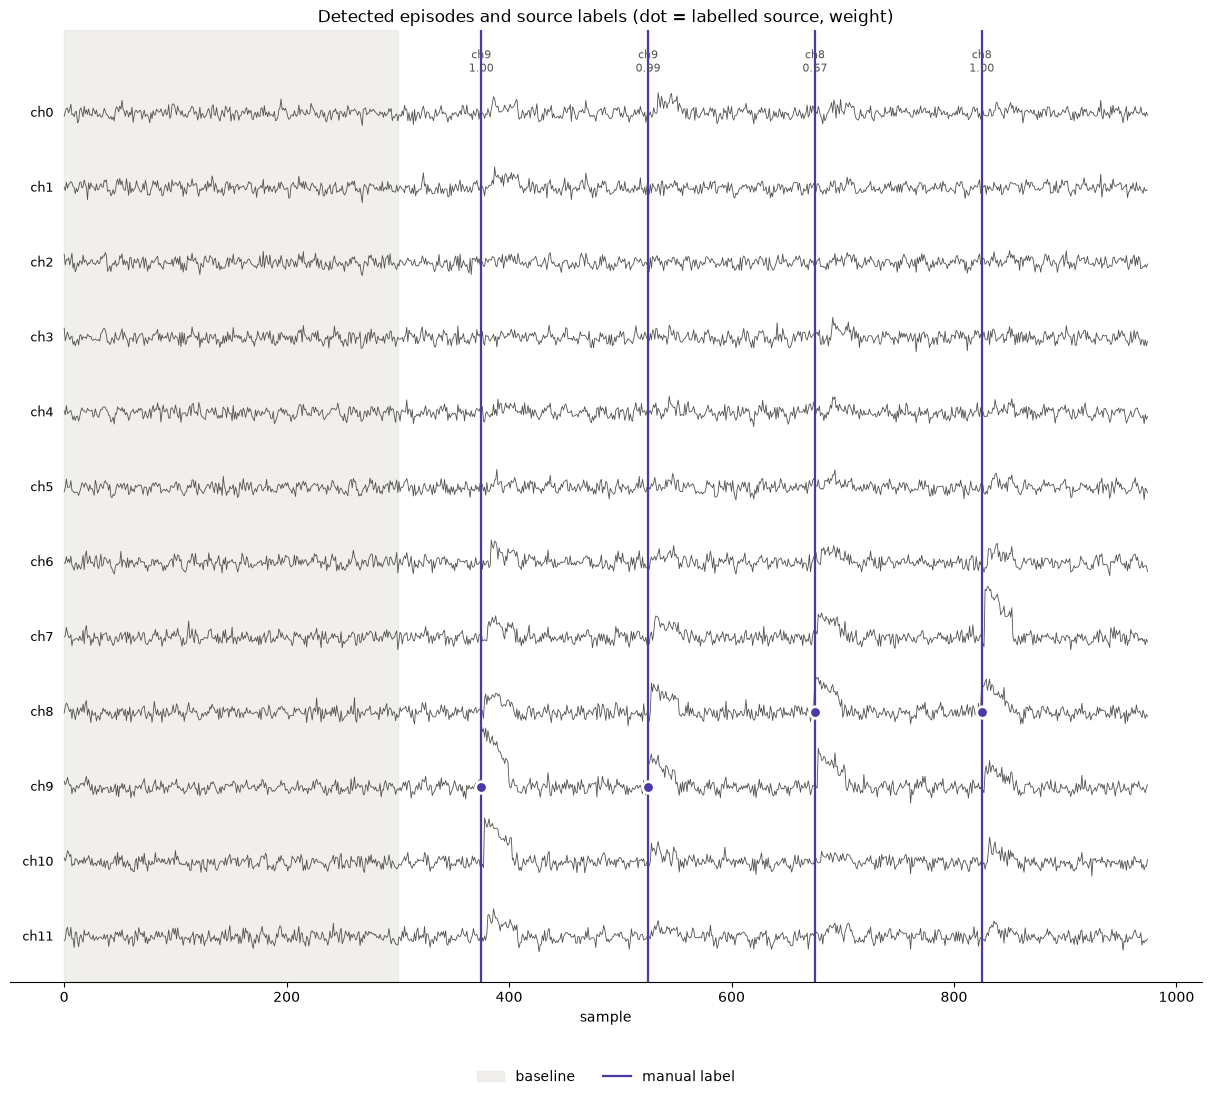

In [4]:
series_id = "training_recording_00"
training_input = training_recordings[series_id]
training_values = np.asarray(training_input.values, dtype=float)
series_labels = [item for item in labels.episodes if item.series_id == series_id]
print("Events in example recording:", len(series_labels))
print(pd.DataFrame([{
    "event_time": item.event_time,
    "source": item.source_name,
    "label_origin": item.origin,
    "confidence": item.confidence,
} for item in series_labels]))

viz.plot_labelled_recording(
    training_values,
    labels,
    series_id=series_id,
    channel_names=[f"ch{index}" for index in range(N_CHANNELS)],
    baseline_size=BASELINE_SIZE,
)
plt.show()

## 3. Обучение с validation progress

`ProcessModelTrainer` обучает GNN/GAT, показывает прогресс по эпохам и сравнивает модели с прозрачной эвристикой. Validation выделяется целыми записями. Синтетические метрики иллюстрируют процедуру; они не обещают качества на реальных данных.

In [5]:
trainer = ProcessModelTrainer(
    GraphLearningConfig(hidden_dim=8, epochs=200, learning_rate=0.02, random_state=SEED),
    validation_fraction=0.25,
    k=3,
    random_state=SEED,
    verbose=True,
)
training_report = trainer.train(labels)
print("Training episodes:", training_report.n_train)
print("Validation episodes:", training_report.n_validation)
print("Validation split unit:", training_report.split_unit)
print("Best validation epoch:", training_report.best_epoch)
training_table = pd.DataFrame(training_report.summary_table())
training_table


Training GNN/GAT:   0%|          | 0/200 [00:00<?, ?it/s]

Training episodes: 71
Validation episodes: 24
Validation split unit: group
Best validation epoch: 180


,split,method,n,top1,top3,mrr,nll
0,train,heuristic,71,0.676056,0.985915,0.822770,1.851757
1,train,gnn,71,0.985915,1.000000,0.992958,0.053662
2,train,gat,71,0.971831,1.000000,0.985915,0.060430
3,validation,heuristic,24,0.500000,0.958333,0.732639,2.054419
4,validation,gnn,24,0.916667,0.958333,0.947917,0.314452
5,validation,gat,24,0.875000,1.000000,0.930556,0.348758


## 4. Отложенные синтетические эпизоды и два CSV-примера

Validation в training report отделён по целым записям; дополнительный тест использует новые seed и известные synthetic ground truth. После него тот же pipeline оценивает fractal 1-D и Kuramoto n-D: первый случай проверяет детекцию относительно `is_extreme`, второй показывает GNN/GAT-предсказания без притворной метки качества. Для n-D входа таблица содержит предсказанный source, а не accuracy.

In [6]:
graph_baseline = build_graph(
    observed_values[:BASELINE_SIZE],
    GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
).adjacency

labeled_test_episodes = [
    make_propagation_episode(
        n_channels=N_CHANNELS,
        source=episode_index % N_CHANNELS,
        baseline_size=BASELINE_SIZE,
        length=600,
        topology="ring",
        gain_jitter=0.45,
        seed=8_000 + episode_index,
    )
    for episode_index in range(12)
]

fractal_onset = int(np.flatnonzero(fractal_frame["is_extreme"].to_numpy())[0])
requested_inputs = [
    EvaluationCase(
        fractal_frame["value"].to_numpy(dtype=float),
        event_time=fractal_onset,
        case_id="1) fractal 1-D",
    ),
    EvaluationCase(
        load_timeseries(DATA_PATH),
        case_id="2) Kuramoto n-D (unlabeled)",
        has_truth=False,
    ),
]
labeled_cases = [
    EvaluationCase.from_synthetic(episode, case_id=f"heldout_synthetic_{index:02d}")
    for index, episode in enumerate(labeled_test_episodes)
]

inference_pipeline = GraphEVTPipeline(
    EVTConfig(
        baseline_size=BASELINE_SIZE,
        tail_quantile=0.90,
        alarm_probability=0.99,
        top_k=3,
        persistence=2,
    ),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    process_model=training_report.model,
    verbose=True,
)
evaluation = EvaluationOrchestrator(
    inference_pipeline, early_tolerance=25, k=3, verbose=True
).evaluate([*labeled_cases, *requested_inputs])
evaluation_frame = pd.DataFrame(evaluation.to_records())
print("Evaluation summary:", evaluation.summary())
evaluation_frame

Evaluating cases:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluation summary: {'1-d': {'cases': 1, 'hit': 1, 'miss': 0, 'early_alarm': 0, 'false_alarm': 0, 'correct_rejection': 0, 'unlabelled': 0, 'detection_rate': 1.0, 'false_alarm_rate': nan, 'mean_delay': 11.0, 'median_delay': 11.0}, 'n-d': {'cases': 13, 'hit': 12, 'miss': 0, 'early_alarm': 0, 'false_alarm': 0, 'correct_rejection': 0, 'unlabelled': 1, 'detection_rate': 1.0, 'false_alarm_rate': nan, 'mean_delay': 0.08333333333333333, 'median_delay': 0.0, 'heuristic_n': 12, 'heuristic_top1': 0.6666666666666666, 'heuristic_top3': 1.0, 'heuristic_mrr': 0.8333333333333334, 'gnn_n': 12, 'gnn_top1': 0.9166666666666666, 'gnn_top3': 1.0, 'gnn_mrr': 0.9444444444444445, 'gat_n': 12, 'gat_top1': 0.9166666666666666, 'gat_top3': 1.0, 'gat_mrr': 0.9583333333333334}}


,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,heldout_synthetic_00,n-d,hit,NaN,320,320.0,0.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0
1,heldout_synthetic_01,n-d,hit,NaN,322,320.0,2.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0
2,heldout_synthetic_02,n-d,hit,NaN,320,320.0,0.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0
3,heldout_synthetic_03,n-d,hit,NaN,320,320.0,0.0,3.0,3.0,1.0,3.0,1.0,3.0,1.0
4,heldout_synthetic_04,n-d,hit,NaN,320,320.0,0.0,4.0,4.0,1.0,4.0,1.0,4.0,1.0
5,heldout_synthetic_05,n-d,hit,NaN,320,320.0,0.0,5.0,5.0,1.0,5.0,1.0,5.0,1.0
6,heldout_synthetic_06,n-d,hit,NaN,320,320.0,0.0,6.0,6.0,1.0,6.0,1.0,6.0,1.0
7,heldout_synthetic_07,n-d,hit,NaN,320,320.0,0.0,7.0,6.0,2.0,7.0,1.0,7.0,1.0
8,heldout_synthetic_08,n-d,hit,NaN,320,320.0,0.0,8.0,8.0,1.0,8.0,1.0,8.0,1.0
9,heldout_synthetic_09,n-d,hit,NaN,319,320.0,-1.0,9.0,9.0,1.0,11.0,3.0,11.0,2.0


## Интерпретация

`EpisodeLabeler` строит EVT-события, baseline-граф и признаки; ручные аннотации задают source labels только для синтетических training recordings. `ProcessModelTrainer` держит целые записи в validation, показывает progress по эпохам и сравнивает GNN/GAT с эвристикой. `EvaluationOrchestrator` показывает progress по mixed 1-D/n-D входам и включает learned scores там, где pipeline локализует событие. Малый synthetic benchmark — проверка исполнения, не оценка обобщения на реальные данные. Для реального исследования нужны независимые размеченные записи и untouched test set.